## Import Dataset, libraries and splitting

In [ ]:
# Import lal drive w unzip lal dataset
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!unzip -q "/content/drive/MyDrive/Colab Notebooks/DSA Final Project/driver_drowsiness_split_ready.zip" -d /content

In [ ]:
# Install required packages (if not already installed, e.g., if running in Colab)
!pip install tensorflow scikit-learn seaborn

# Import libraries
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
import shutil
from tensorflow.keras import layers

# Verify GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU is available: {gpus[0].name}")
else:
    print("GPU not available, using CPU.")

In [ ]:
#    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=SEED)
#    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=SEED)

from sklearn.model_selection import train_test_split
import shutil

## Split the data between Train/Test/Validation
# Set paths
RAW_DIR = "Driver Drowsiness Dataset (DDD) - RAW"
TARGET_DIR = "Driver Drowsiness Dataset (DDD)"
SEED = 42

# Create target folder structure
for subset in ['train', 'val', 'test']:
    for cls in ['drowsy', 'alert']:
        os.makedirs(os.path.join(TARGET_DIR, subset, cls), exist_ok=True)

# Helper to split and copy files with progress messages
def split_and_copy(class_name, target_class_name):
    src_folder = os.path.join(RAW_DIR, class_name)
    images = os.listdir(src_folder)
    total_images = len(images)

    print(f"\n[{class_name} → {target_class_name}] Total images found: {total_images}")

    # Split 70% train, 15% val, 15% test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=SEED)

    for subset_name, file_list in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        print(f" → Copying {len(file_list)} images to {subset_name}/{target_class_name}")
        for idx, img in enumerate(file_list, start=1):
            src = os.path.join(src_folder, img)
            dst = os.path.join(TARGET_DIR, subset_name, target_class_name, img)
            shutil.copy2(src, dst)

            if idx % 500 == 0 or idx == len(file_list):
                print(f"    Copied {idx}/{len(file_list)} images")

# Perform split
split_and_copy('Drowsy', 'drowsy')
split_and_copy('Non Drowsy', 'alert')


[Drowsy → drowsy] Total images found: 22348
 → Copying 15643 images to train/drowsy
    Copied 500/15643 images
    Copied 1000/15643 images
    Copied 1500/15643 images
    Copied 2000/15643 images
    Copied 2500/15643 images
    Copied 3000/15643 images
    Copied 3500/15643 images
    Copied 4000/15643 images
    Copied 4500/15643 images
    Copied 5000/15643 images
    Copied 5500/15643 images
    Copied 6000/15643 images
    Copied 6500/15643 images
    Copied 7000/15643 images
    Copied 7500/15643 images
    Copied 8000/15643 images
    Copied 8500/15643 images
    Copied 9000/15643 images
    Copied 9500/15643 images
    Copied 10000/15643 images
    Copied 10500/15643 images
    Copied 11000/15643 images
    Copied 11500/15643 images
    Copied 12000/15643 images
    Copied 12500/15643 images
    Copied 13000/15643 images
    Copied 13500/15643 images
    Copied 14000/15643 images
    Copied 14500/15643 images
    Copied 15000/15643 images
    Copied 15500/15643 images
    C

In [ ]:
# importing datasets as tensors
# Parameters
IMG_SIZE = (224, 224)         # Image dimensions
BATCH_SIZE = 32               # Batch size
SEED = 42                     # For reproducibility
DATASET_PATH = "Driver Drowsiness Dataset (DDD)"  # Where your split folders are located

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=f"{DATASET_PATH}/train",
    label_mode='binary',           # Binary labels: 0 for alert, 1 for drowsy
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=f"{DATASET_PATH}/val",
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    directory=f"{DATASET_PATH}/test",
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

# Optimize performance (prefetch batches)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 29254 files belonging to 2 classes.
Found 6269 files belonging to 2 classes.
Found 6270 files belonging to 2 classes.


In [ ]:
#We have verified the count of images in each tensor dataset
def get_exact_sample_count(ds, name):
    count = sum(1 for _ in ds.unbatch())
    print(f"✅ {name} dataset contains {count} exact samples")
    return count

total_train = get_exact_sample_count(train_ds, "Train")
total_val = get_exact_sample_count(val_ds, "Validation")
total_test = get_exact_sample_count(test_ds, "Test")

print(f"🎯 Total samples: {total_train + total_val + total_test}")

✅ Train dataset contains 29254 exact samples
✅ Validation dataset contains 6269 exact samples
✅ Test dataset contains 6270 exact samples
🎯 Total samples: 41793


In [ ]:
def count_samples_by_class(dataset, name):
    alert_count = 0
    drowsy_count = 0

    for _, labels in dataset.unbatch():
        if labels.numpy() == 0:
            alert_count += 1
        else:
            drowsy_count += 1

    total = alert_count + drowsy_count
    print(f"📊 {name} Set:")
    print(f"   - Alert  (label 0): {alert_count}")
    print(f"   - Drowsy (label 1): {drowsy_count}")
    print(f"   - Total            : {total}")
    return alert_count, drowsy_count


train_alert, train_drowsy = count_samples_by_class(train_ds, "Train")
val_alert, val_drowsy = count_samples_by_class(val_ds, "Validation")
test_alert, test_drowsy = count_samples_by_class(test_ds, "Test")

# Now calculate totals for raw
raw_alert = train_alert + val_alert + test_alert
raw_drowsy = train_drowsy + val_drowsy + test_drowsy

📊 Train Set:
   - Alert  (label 0): 13611
   - Drowsy (label 1): 15643
   - Total            : 29254
📊 Validation Set:
   - Alert  (label 0): 2917
   - Drowsy (label 1): 3352
   - Total            : 6269
📊 Test Set:
   - Alert  (label 0): 2917
   - Drowsy (label 1): 3353
   - Total            : 6270


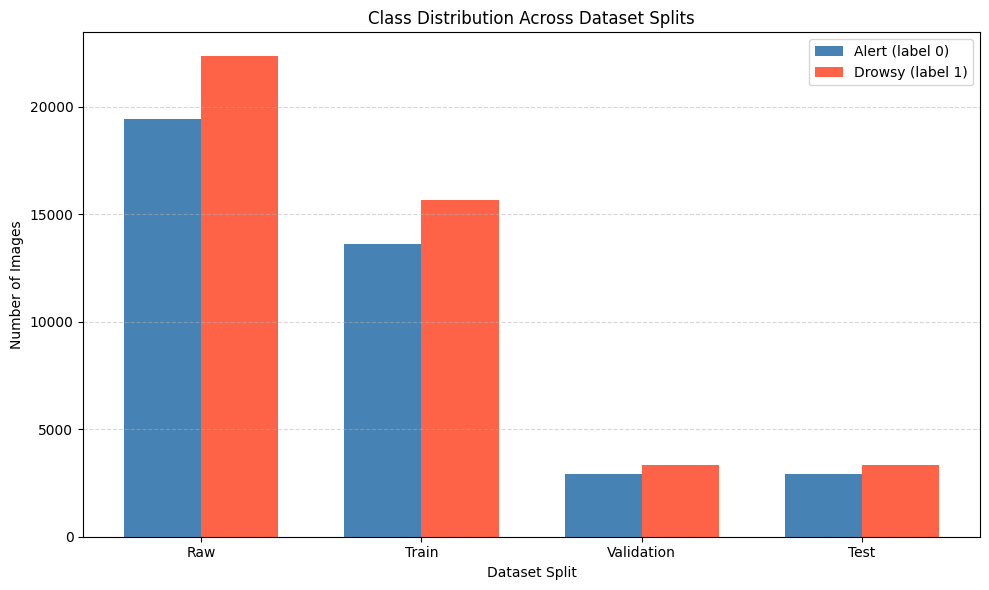

In [ ]:
# Balance between the different classes : Drowsy/Non-Drowsy
# Dataset labels
sets = ['Raw', 'Train', 'Validation', 'Test']

# Class-wise counts (no manual input 🎉)
alert_counts = [raw_alert, train_alert, val_alert, test_alert]
drowsy_counts = [raw_drowsy, train_drowsy, val_drowsy, test_drowsy]

x = range(len(sets))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x, alert_counts, width, label='Alert (label 0)', color='steelblue')
plt.bar([i + width for i in x], drowsy_counts, width, label='Drowsy (label 1)', color='tomato')

# Formatting
plt.xlabel('Dataset Split')
plt.ylabel('Number of Images')
plt.title('Class Distribution Across Dataset Splits')
plt.xticks([i + width / 2 for i in x], sets)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## EfficientNetB5

In [ ]:
from tensorflow.keras.applications import EfficientNetB5

base_model = EfficientNetB5(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
print(f"Total layers: {len(base_model.layers)}")


115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layers: 577


In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.applications.efficientnet import preprocess_input

def create_model(
    input_shape=(224, 224, 3),
    num_dense=1,                  # How many dense layers to add
    start_units=512,              # Starting units for pyramid
    dropout_rate=0.5,             # Dropout applied before each Dense
    unfreeze_top_k=0,             # Number of top EfficientNet layers to unfreeze
    learning_rate=1e-3            # Learning rate for optimizer
):
    # Load EfficientNetB5 base model
    base_model = EfficientNetB5(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze all layers initially
    base_model.trainable = False

    # Unfreeze top-k layers if specified
    if unfreeze_top_k > 0:
        for layer in base_model.layers[-unfreeze_top_k:]:
            layer.trainable = True

    # Input layer
    inputs = layers.Input(shape=input_shape)

    # Preprocessing (EfficientNet requires normalization)
    x = preprocess_input(inputs)

    # Base model
    x = base_model(x, training=False)

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Pyramid-style dense layers
    for i in range(num_dense):
        units = int(start_units * (0.5 ** i))  # 512 → 256 → 128 → ...
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(units, activation='relu')(x)

    # Final binary classification output
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Assemble model
    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# Trial configuration list
model_configs = {
    "Model A": {"num_dense": 1, "start_units": 512, "dropout_rate": 0.5, "unfreeze_top_k": 0},
}

# To store results
histories = {}

# Run training for each model
for name, config in model_configs.items():
    print(f"\n🚀 Training {name} with config: {config}")
    model = create_model(
        num_dense=config["num_dense"],
        start_units=config["start_units"],
        dropout_rate=config["dropout_rate"],
        unfreeze_top_k=config["unfreeze_top_k"],
        learning_rate=1e-3  # You can tune this later
    )

    history = model.fit(
        train_ds_plain,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )

    histories[name] = history
    model.save(f"/content/{name}_b5_trial_model.keras")



🚀 Training Model A with config: {'num_dense': 1, 'start_units': 512, 'dropout_rate': 0.5, 'unfreeze_top_k': 0}
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 247s 206ms/step - accuracy: 0.9238 - loss: 0.1712 - val_accuracy: 0.9992 - val_loss: 0.0028
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 139s 152ms/step - accuracy: 0.9949 - loss: 0.0159 - val_accuracy: 0.9998 - val_loss: 8.8784e-04
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 141s 154ms/step - accuracy: 0.9963 - loss: 0.0104 - val_accuracy: 0.9995 - val_loss: 8.5967e-04


In [ ]:
#Force CPU usage
import tensorflow as tf
import time

# ✅ Load the model into CPU memory
with tf.device('/CPU:0'):
    cpu_model = tf.keras.models.load_model("/content/Model A_b5_trial_model.keras")

# ✅ Get one batch (32 images) from the validation set
for images, _ in val_ds.take(1):
    test_batch = images  # shape: (32, 224, 224, 3)

# ✅ Run inference timing on CPU
with tf.device('/CPU:0'):
    _ = cpu_model.predict(test_batch)  # Warm-up pass

    start = time.time()
    _ = cpu_model.predict(test_batch)
    end = time.time()

    total_time = (end - start) * 1000  # in milliseconds
    avg_time_per_image = total_time / len(test_batch)

    print(f"🧪 Batch Inference Time: {total_time:.2f} ms for {len(test_batch)} images")
    print(f"🕒 Avg Time per Image: {avg_time_per_image:.2f} ms")


1/1 ━━━━━━━━━━━━━━━━━━━━ 81s 81s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 71s 71s/step
🧪 Batch Inference Time: 81948.38 ms for 32 images
🕒 Avg Time per Image: 2560.89 ms


## EfficientNetB3

In [ ]:
from tensorflow.keras.applications import EfficientNetB3

base_model = EfficientNetB3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
print(f"Total layers: {len(base_model.layers)}")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers: 385


In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

def create_model(
    input_shape=(224, 224, 3),
    num_dense=1,                  # How many dense layers to add
    start_units=384,              # Starting units for pyramid
    dropout_rate=0.5,             # Dropout applied before each Dense
    unfreeze_top_k=0,             # Number of top EfficientNet layers to unfreeze
    learning_rate=1e-3            # Learning rate for optimizer
):
    # Load EfficientNetB3 base model
    base_model = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze all layers initially
    base_model.trainable = False

    # Unfreeze top-k layers if specified
    if unfreeze_top_k > 0:
        for layer in base_model.layers[-unfreeze_top_k:]:
            layer.trainable = True

    # Input layer
    inputs = layers.Input(shape=input_shape)

    # Preprocessing (EfficientNet requires normalization)
    x = preprocess_input(inputs)

    # Base model
    x = base_model(x, training=False)

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Pyramid-style dense layers
    for i in range(num_dense):
        units = int(start_units * (0.5 ** i))  # 384 → 192 → 96 ...
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(units, activation='relu')(x)

    # Final binary classification output
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Assemble model
    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# Trial configuration list
model_configs = {
    "Model A": {"num_dense": 1, "start_units": 512, "dropout_rate": 0.5, "unfreeze_top_k": 0},
}

# To store results
histories = {}

# Run training for each model
for name, config in model_configs.items():
    print(f"\n🚀 Training {name} with config: {config}")
    model = create_model(
        num_dense=config["num_dense"],
        start_units=config["start_units"],
        dropout_rate=config["dropout_rate"],
        unfreeze_top_k=config["unfreeze_top_k"],
        learning_rate=1e-3  # You can tune this later
    )

    history = model.fit(
        train_ds_plain,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )

    histories[name] = history
    model.save(f"/content/{name}_b3_trial_model.keras")



🚀 Training Model A with config: {'num_dense': 1, 'start_units': 512, 'dropout_rate': 0.5, 'unfreeze_top_k': 0}
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 150s 123ms/step - accuracy: 0.9232 - loss: 0.1806 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 84s 92ms/step - accuracy: 0.9952 - loss: 0.0169 - val_accuracy: 0.9992 - val_loss: 0.0035
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 92s 100ms/step - accuracy: 0.9969 - loss: 0.0108 - val_accuracy: 0.9989 - val_loss: 0.0040


In [ ]:
import tensorflow as tf
import time

# ✅ Load the model into CPU memory
with tf.device('/CPU:0'):
    cpu_model = tf.keras.models.load_model("/content/Model A_b3_trial_model.keras")

# ✅ Get one batch (32 images) from the validation set
for images, _ in val_ds.take(1):
    test_batch = images  # shape: (32, 224, 224, 3)

# ✅ Run inference timing on CPU
with tf.device('/CPU:0'):
    _ = cpu_model.predict(test_batch)  # Warm-up pass

    start = time.time()
    _ = cpu_model.predict(test_batch)
    end = time.time()

    total_time = (end - start) * 1000  # in milliseconds
    avg_time_per_image = total_time / len(test_batch)

    print(f"🧪 Batch Inference Time: {total_time:.2f} ms for {len(test_batch)} images")
    print(f"🕒 Avg Time per Image: {avg_time_per_image:.2f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 44s 44s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 34s 34s/step
🧪 Batch Inference Time: 33752.60 ms for 32 images
🕒 Avg Time per Image: 1054.77 ms


## EfficientNetB1

In [ ]:
from tensorflow.keras.applications import EfficientNetB1

base_model = EfficientNetB1(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

print(f"Total layers: {len(base_model.layers)}")

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers: 340


In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input

def create_model(
    input_shape=(224, 224, 3),
    num_dense=1,                  # How many dense layers to add
    start_units=384,              # Starting units for pyramid
    dropout_rate=0.5,             # Dropout applied before each Dense
    unfreeze_top_k=0,             # Number of top EfficientNet layers to unfreeze
    learning_rate=1e-3            # Learning rate for optimizer
):
    # Load EfficientNetB1 base model
    base_model = EfficientNetB1(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze all layers initially
    base_model.trainable = False

    # Unfreeze top-k layers if specified
    if unfreeze_top_k > 0:
        for layer in base_model.layers[-unfreeze_top_k:]:
            layer.trainable = True

    # Input layer
    inputs = layers.Input(shape=input_shape)

    # Preprocessing (EfficientNet requires normalization)
    x = preprocess_input(inputs)

    # Base model
    x = base_model(x, training=False)

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Pyramid-style dense layers
    for i in range(num_dense):
        units = int(start_units * (0.5 ** i))  # 384 → 192 → 96 ...
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(units, activation='relu')(x)

    # Final binary classification output
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Assemble model
    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# Trial configuration list (adapted for EfficientNetB1)
model_configs = {
    "Model A": {"num_dense": 1, "start_units": 384, "dropout_rate": 0.5, "unfreeze_top_k": 0},
}

# To store results
histories = {}

# Run training for each model
for name, config in model_configs.items():
    print(f"\n🚀 Training {name} with config: {config}")

    model = create_model(
        num_dense=config["num_dense"],
        start_units=config["start_units"],
        dropout_rate=config["dropout_rate"],
        unfreeze_top_k=config["unfreeze_top_k"],
        learning_rate=1e-3
    )

    history = model.fit(
        train_ds_plain,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )

    histories[name] = history

    # Save model with proper extension
    model.save(f"/content/{name}_b1_trial_model.keras")
    model.save("/content/drive/MyDrive/Colab Notebooks/DSA Final Project/Model A_b1_trial_model.keras")


🚀 Training Model A with config: {'num_dense': 1, 'start_units': 384, 'dropout_rate': 0.5, 'unfreeze_top_k': 0}
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 166s 143ms/step - accuracy: 0.9175 - loss: 0.1875 - val_accuracy: 0.9997 - val_loss: 0.0024
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 159s 117ms/step - accuracy: 0.9943 - loss: 0.0198 - val_accuracy: 0.9995 - val_loss: 0.0016
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 119s 92ms/step - accuracy: 0.9968 - loss: 0.0102 - val_accuracy: 0.9994 - val_loss: 0.0027


In [ ]:
import tensorflow as tf
import time

# ✅ Load the model into CPU memory
with tf.device('/CPU:0'):
    cpu_model = tf.keras.models.load_model("/content/Model A_b1_trial_model.keras")

# ✅ Get one batch (32 images) from the validation set
for images, _ in val_ds.take(1):
    test_batch = images  # shape: (32, 224, 224, 3)

# ✅ Run inference timing on CPU
with tf.device('/CPU:0'):
    _ = cpu_model.predict(test_batch)  # Warm-up pass

    start = time.time()
    _ = cpu_model.predict(test_batch)
    end = time.time()

    total_time = (end - start) * 1000  # in milliseconds
    avg_time_per_image = total_time / len(test_batch)

    print(f"🧪 Batch Inference Time: {total_time:.2f} ms for {len(test_batch)} images")
    print(f"🕒 Avg Time per Image: {avg_time_per_image:.2f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 33s 33s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step
🧪 Batch Inference Time: 25947.90 ms for 32 images
🕒 Avg Time per Image: 810.87 ms


## EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

print(f"Total layers: {len(base_model.layers)}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers: 238


In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input

def create_model(
    input_shape=(224, 224, 3),
    num_dense=1,                  # How many dense layers to add
    start_units=384,              # Starting units for pyramid
    dropout_rate=0.5,             # Dropout applied before each Dense
    unfreeze_top_k=0,             # Number of top EfficientNet layers to unfreeze
    learning_rate=1e-3            # Learning rate for optimizer
):
    # Load EfficientNetB1 base model
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze all layers initially
    base_model.trainable = False

    # Unfreeze top-k layers if specified
    if unfreeze_top_k > 0:
        for layer in base_model.layers[-unfreeze_top_k:]:
            layer.trainable = True

    # Input layer
    inputs = layers.Input(shape=input_shape)

    # Preprocessing (EfficientNet requires normalization)
    x = preprocess_input(inputs)

    # Base model
    x = base_model(x, training=False)

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Pyramid-style dense layers
    for i in range(num_dense):
        units = int(start_units * (0.5 ** i))  # 384 → 192 → 96 ...
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(units, activation='relu')(x)

    # Final binary classification output
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Assemble model
    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# Trial configuration list (adapted for EfficientNetB1)
model_configs = {
    "Model A": {"num_dense": 1, "start_units": 384, "dropout_rate": 0.5, "unfreeze_top_k": 0},
}

# To store results
histories = {}

# Run training for each model
for name, config in model_configs.items():
    print(f"\n🚀 Training {name} with config: {config}")

    model = create_model(
        num_dense=config["num_dense"],
        start_units=config["start_units"],
        dropout_rate=config["dropout_rate"],
        unfreeze_top_k=config["unfreeze_top_k"],
        learning_rate=1e-3
    )

    history = model.fit(
        train_ds_plain,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )

    histories[name] = history

    # Save model with proper extension
    model.save(f"/content/{name}_b0_trial_model.keras")
    model.save("/content/drive/MyDrive/Colab Notebooks/DSA Final Project/Model A_b0_trial_model.keras")


🚀 Training Model A with config: {'num_dense': 1, 'start_units': 384, 'dropout_rate': 0.5, 'unfreeze_top_k': 0}
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 163s 134ms/step - accuracy: 0.9048 - loss: 0.2131 - val_accuracy: 0.9982 - val_loss: 0.0062
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 91s 93ms/step - accuracy: 0.9933 - loss: 0.0226 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 74s 81ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9997 - val_loss: 0.0014


In [ ]:
import tensorflow as tf
import time

# ✅ Load the model into CPU memory
with tf.device('/CPU:0'):
    cpu_model = tf.keras.models.load_model("/content/Model A_b0_trial_model.keras")

# ✅ Get one batch (32 images) from the validation set
for images, _ in val_ds.take(1):
    test_batch = images  # shape: (32, 224, 224, 3)

# ✅ Run inference timing on CPU
with tf.device('/CPU:0'):
    _ = cpu_model.predict(test_batch)  # Warm-up pass

    start = time.time()
    _ = cpu_model.predict(test_batch)
    end = time.time()

    total_time = (end - start) * 1000  # in milliseconds
    avg_time_per_image = total_time / len(test_batch)

    print(f"🧪 Batch Inference Time: {total_time:.2f} ms for {len(test_batch)} images")
    print(f"🕒 Avg Time per Image: {avg_time_per_image:.2f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
🧪 Batch Inference Time: 15895.25 ms for 32 images
🕒 Avg Time per Image: 496.73 ms


## MobileV3‑Small

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# ─── Create a MobileNetV3‑Small‑based model ────────────────────────────────────
def create_model(
    input_shape=(224, 224, 3),
    num_dense=1,
    start_units=384,
    dropout_rate=0.5,
    unfreeze_top_k=0,
    learning_rate=1e-3
):
    # Load MobileNetV3‑Small base model
    base_model = MobileNetV3Small(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base_model.trainable = False

    if unfreeze_top_k > 0:
        for layer in base_model.layers[-unfreeze_top_k:]:
            layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    for i in range(num_dense):
        units = int(start_units * (0.5 ** i))
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(units, activation='relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ─── Training loop ────────────────────────────────────────────────────────────
model_configs = {
    "Model A": {"num_dense": 1, "start_units": 384, "dropout_rate": 0.5, "unfreeze_top_k": 0},
    "Model B": {"num_dense": 2, "start_units": 384, "dropout_rate": 0.3, "unfreeze_top_k": 0},
    "Model C": {"num_dense": 2, "start_units": 384, "dropout_rate": 0.3, "unfreeze_top_k": 20},
    "Model D": {"num_dense": 3, "start_units": 384, "dropout_rate": 0.3, "unfreeze_top_k": 40},
    "Model E": {"num_dense": 2, "start_units": 256, "dropout_rate": 0.5, "unfreeze_top_k": 20},
    "Model F": {"num_dense": 3, "start_units": 256, "dropout_rate": 0.3, "unfreeze_top_k": 40},
    "Model G": {"num_dense": 3, "start_units": 384, "dropout_rate": 0.3, "unfreeze_top_k": 60}
}

histories = {}

for name, cfg in model_configs.items():
    print(f"\n🚀 Training {name} with config: {cfg}")
    model = create_model(
        num_dense=cfg["num_dense"],
        start_units=cfg["start_units"],
        dropout_rate=cfg["dropout_rate"],
        unfreeze_top_k=cfg["unfreeze_top_k"],
        learning_rate=1e-3
    )

    history = model.fit(
        train_ds_augmented,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )
    histories[name] = history

    # Save model using model name
    model.save(f"/content/{name}_trial_model.keras")
    model.save(f"/content/drive/MyDrive/Colab Notebooks/DSA Final Project/{name}_MobileV3-Small.keras")




🚀 Training Model A with config: {'num_dense': 1, 'start_units': 384, 'dropout_rate': 0.5, 'unfreeze_top_k': 0}
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 424s 452ms/step - accuracy: 0.8004 - loss: 0.4093 - val_accuracy: 0.9844 - val_loss: 0.0774
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 424s 438ms/step - accuracy: 0.9572 - loss: 0.1208 - val_accuracy: 0.9949 - val_loss: 0.0262
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 445s 441ms/step - accuracy: 0.9797 - loss: 0.0635 - val_accuracy: 0.9974 - val_loss: 0.0134

🚀 Training Model B with config: {'num_dense': 2, 'start_units': 384, 'dropout_rate': 0.3, 'unfreeze_top_k': 0}
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 419s 446ms/step - accuracy: 0.8313 - loss: 0.3413 - val_accuracy: 0.9917 - val_loss: 0.0357
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 409s 446ms/step - accuracy: 0.9723 - loss: 0.0748 - val_accuracy: 0.9957 - val_loss: 0.0154
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 399s 436ms/step - accuracy: 0.9835 - loss: 0.0480 - val_accuracy: 0.9978 - val_los

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# ─── Create a MobileNetV3‑Small‑based model ────────────────────────────────────
def create_model(
    input_shape=(224, 224, 3),
    num_dense=1,
    start_units=384,
    dropout_rate=0.5,
    unfreeze_top_k=0,
    learning_rate=1e-3
):
    # Load MobileNetV3‑Small base model
    base_model = MobileNetV3Small(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base_model.trainable = False

    if unfreeze_top_k > 0:
        for layer in base_model.layers[-unfreeze_top_k:]:
            layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    for i in range(num_dense):
        units = int(start_units * (0.5 ** i))
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(units, activation='relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ─── Training loop ────────────────────────────────────────────────────────────
model_configs = {
    "Model F": {"num_dense": 3, "start_units": 256, "dropout_rate": 0.3, "unfreeze_top_k": 40},
    "Model G": {"num_dense": 3, "start_units": 384, "dropout_rate": 0.3, "unfreeze_top_k": 60}
}

histories = {}

for name, cfg in model_configs.items():
    print(f"\n🚀 Training {name} with config: {cfg}")
    model = create_model(
        num_dense=cfg["num_dense"],
        start_units=cfg["start_units"],
        dropout_rate=cfg["dropout_rate"],
        unfreeze_top_k=cfg["unfreeze_top_k"],
        learning_rate=1e-3
    )

    history = model.fit(
        train_ds_augmented,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )
    histories[name] = history

    # Save model using model name
    model.save(f"/content/{name}_trial_model.keras")
    model.save(f"/content/drive/MyDrive/Colab Notebooks/DSA Final Project/{name}_MobileV3-Small.keras")




🚀 Training Model F with config: {'num_dense': 3, 'start_units': 256, 'dropout_rate': 0.3, 'unfreeze_top_k': 40}
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 458s 476ms/step - accuracy: 0.9255 - loss: 0.1504 - val_accuracy: 0.9884 - val_loss: 0.1388
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 403s 440ms/step - accuracy: 0.9977 - loss: 0.0075 - val_accuracy: 0.9955 - val_loss: 0.0185
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 412s 450ms/step - accuracy: 0.9984 - loss: 0.0065 - val_accuracy: 0.9716 - val_loss: 0.3021

🚀 Training Model G with config: {'num_dense': 3, 'start_units': 384, 'dropout_rate': 0.3, 'unfreeze_top_k': 60}
Epoch 1/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 441s 456ms/step - accuracy: 0.9417 - loss: 0.1282 - val_accuracy: 0.9679 - val_loss: 0.2350
Epoch 2/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 403s 440ms/step - accuracy: 0.9972 - loss: 0.0106 - val_accuracy: 0.9847 - val_loss: 0.3221
Epoch 3/3
915/915 ━━━━━━━━━━━━━━━━━━━━ 446s 444ms/step - accuracy: 0.9

In [ ]:
# ─── Inference timing on CPU ─────────────────────────────────────────────────
with tf.device('/CPU:0'):
    cpu_model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/DSA Final Project/Model A_MobileV3-Small.keras")

# grab one batch
for images, _ in val_ds.take(1):
    test_batch = images  # e.g. (32,224,224,3)

with tf.device('/CPU:0'):
    # warm‑up
    _ = cpu_model.predict(test_batch)

    start = time.time()
    _ = cpu_model.predict(test_batch)
    end = time.time()

total_ms = (end - start) * 1000
print(f"\n🧪 Batch Inference Time: {total_ms:.2f} ms for {len(test_batch)} images")
print(f"🕒 Avg Time per Image: {total_ms/len(test_batch):.2f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

🧪 Batch Inference Time: 5147.26 ms for 32 images
🕒 Avg Time per Image: 160.85 ms


In [ ]:
# ✅ Define real-time augmentation pipeline (applied only during training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),    # Flip left–right
    layers.RandomRotation(0.1, seed=SEED),         # Rotate ±10%
    layers.RandomZoom(0.15, seed=SEED),            # Zoom ±15%
    layers.RandomContrast(0.2, seed=SEED),         # Contrast ±20%
], name="data_augmentation")

print("✅ Data augmentation pipeline defined.")

# A. Original training dataset (no augmentation)
train_ds_plain = train_ds.map(lambda x, y: (x, y))

# B. Augmented training dataset (real-time augmentation)
train_ds_augmented = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

print("✅ Prepared both plain and augmented training datasets.")

✅ Data augmentation pipeline defined.
✅ Prepared both plain and augmented training datasets.


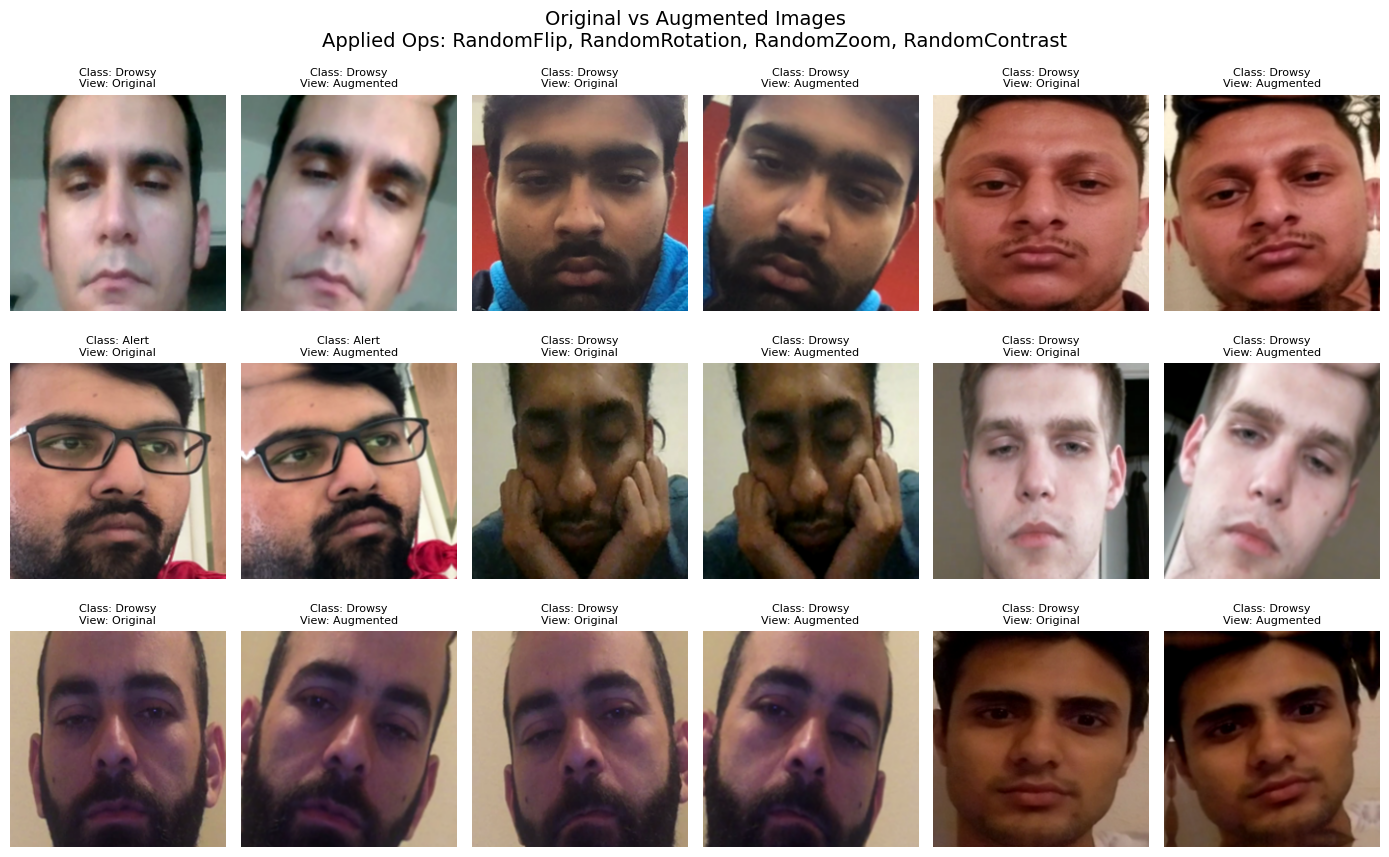

In [ ]:
# Show 9 pairs of (original, augmented) images side-by-side
for images, labels in train_ds.unbatch().batch(9).take(1):
    plt.figure(figsize=(14, 9))
    for i in range(9):
        original = images[i].numpy().astype("uint8")
        augmented = data_augmentation(images, training=True)[i].numpy().astype("uint8")
        label_text = "Drowsy" if labels[i].numpy() == 1 else "Alert"

        # Show original image
        plt.subplot(3, 6, i * 2 + 1)
        plt.imshow(original)
        plt.title(f"Class: {label_text}\nView: Original", fontsize=8)
        plt.axis("off")

        # Show augmented image
        plt.subplot(3, 6, i * 2 + 2)
        plt.imshow(augmented)
        plt.title(f"Class: {label_text}\nView: Augmented", fontsize=8)
        plt.axis("off")

    plt.suptitle("Original vs Augmented Images\nApplied Ops: RandomFlip, RandomRotation, RandomZoom, RandomContrast", fontsize=14)
    plt.tight_layout()
    plt.show()
    break

🚀 Training Final Model C...
Epoch 1/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 438s 380ms/step - accuracy: 0.8390 - loss: 0.3281 - learning_rate: 1.0000e-04
Epoch 2/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 408s 367ms/step - accuracy: 0.9400 - loss: 0.1875 - learning_rate: 1.0000e-04
Epoch 3/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 441s 366ms/step - accuracy: 0.9705 - loss: 0.0871 - learning_rate: 1.0000e-04
Epoch 4/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 402s 361ms/step - accuracy: 0.9761 - loss: 0.0596 - learning_rate: 1.0000e-04
Epoch 5/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 398s 358ms/step - accuracy: 0.9798 - loss: 0.0493 - learning_rate: 1.0000e-04
Epoch 6/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 405s 364ms/step - accuracy: 0.9914 - loss: 0.0241 - learning_rate: 1.0000e-04
Epoch 7/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 401s 360ms/step - accuracy: 0.9960 - loss: 0.0173 - learning_rate: 1.0000e-04
Epoch 8/30
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 399s 359ms/step - accuracy: 0.9970 - loss: 0.0120 - learning_rate: 1.0000e-04
Epoch 9/30
1

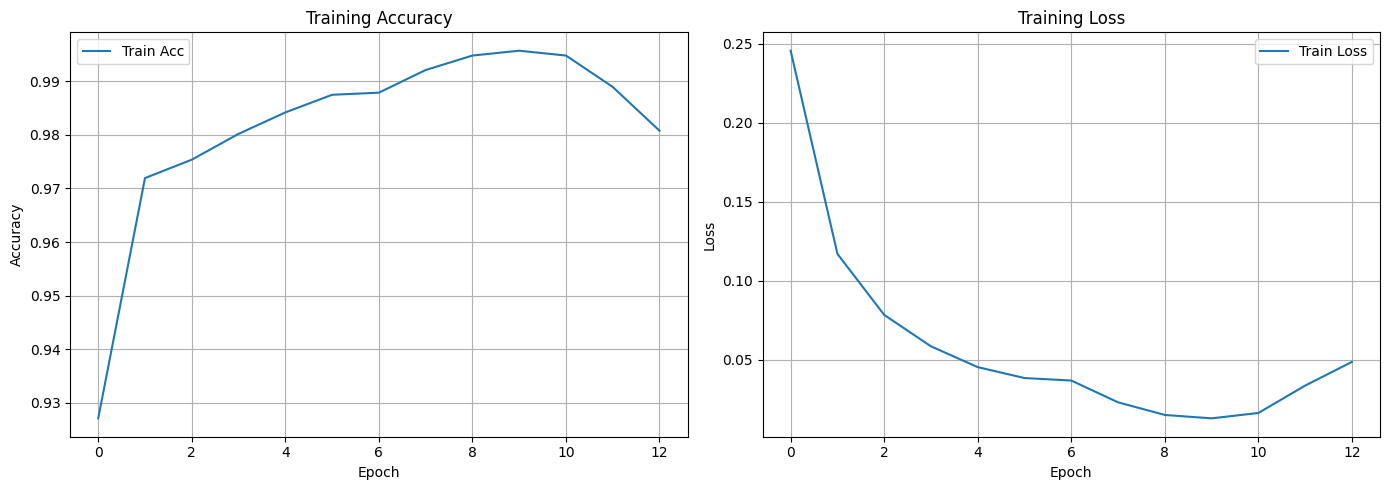

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ─── Build Model Function ─────────────────────────────────────────────────────
def create_model(input_shape=(224, 224, 3), num_dense=2, start_units=384,
                 dropout_rate=0.3, unfreeze_top_k=20, learning_rate=1e-4):
    base_model = MobileNetV3Small(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False

    if unfreeze_top_k > 0:
        for layer in base_model.layers[-unfreeze_top_k:]:
            layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs)
    x = base_model(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)

    for i in range(num_dense):
        units = int(start_units * (0.5 ** i))
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(units, activation='relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ─── Callbacks ────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# ─── Final Dataset ────────────────────────────────────────────────────────────
final_train_ds = train_ds_augmented.concatenate(val_ds)

# ─── Create and Train Model C ─────────────────────────────────────────────────
print("🚀 Training Final Model C...")
model_c = create_model()

history = model_c.fit(
    final_train_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ─── Save Final Model Locally & to Drive ──────────────────────────────────────
model_c.save("/content/ModelC_final.keras")
model_c.save("/content/drive/MyDrive/Colab Notebooks/DSA Final Project/ModelC_final_MobileV3-Small.keras")

# ─── Evaluate on Test Dataset ────────────────────────────────────────────────
test_loss, test_acc = model_c.evaluate(test_ds, verbose=1)
print(f"🧪 Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# ─── Plot Learning Curves ─────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## TF Lite

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf

# ─── Enable XNNPACK for best CPU performance ─────────────────────────────────
os.environ['TF_ENABLE_XNNPACK'] = '1'

# ─── 1) Load your trained Keras model ──────────────────────────────────────────
model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/DSA Final Project/ModelC_final_MobileV3-Small.keras")

# ─── 2) Conversion helper ──────────────────────────────────────────────────────
def convert_to_tflite(model, quant=None):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    if quant == 'dynamic':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    elif quant == 'float16':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

# ─── 3) Extract ~1000 samples from val_ds_plain ────────────────────────────────
def prepare_numpy_data(ds, max_samples=1000):
    xs, ys = [], []
    for x_batch, y_batch in ds:
        xs.append(x_batch.numpy())
        ys.append(y_batch.numpy())
        if sum(x.shape[0] for x in xs) >= max_samples:
            break
    x = np.concatenate(xs)[:max_samples]
    y = np.concatenate(ys)[:max_samples]
    return x, y

x_val, y_val = prepare_numpy_data(val_ds, max_samples=1000)
print("Using", len(x_val), "samples for evaluation")

# ─── 4) TFLite evaluation with multi-threaded CPU ─────────────────────────────
def evaluate_tflite(tflite_model, x_data, y_data):
    num_threads = os.cpu_count() or 1
    interpreter = tf.lite.Interpreter(
        model_content=tflite_model,
        num_threads=num_threads
    )
    interpreter.allocate_tensors()

    # After interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()[0]
    print("→ Model expects input shape:", input_details['shape'])
    print("→ Model expects dtype     :", input_details['dtype'])
    print("→ Model quantization     :", input_details.get('quantization', None))

    inp_idx = interpreter.get_input_details()[0]['index']
    out_idx = interpreter.get_output_details()[0]['index']

    # Warm‑up
    dummy = np.expand_dims(x_data[0].astype(np.float32), 0)
    for _ in range(5):
        interpreter.set_tensor(inp_idx, dummy)
        interpreter.invoke()

    # Timed loop
    times = []
    correct = 0
    for img, label in zip(x_data, y_data):
        inp = np.expand_dims(img.astype(np.float32), 0)
        start = time.time()
        interpreter.set_tensor(inp_idx, inp)
        interpreter.invoke()
        elapsed = (time.time() - start) * 1000  # ms
        times.append(elapsed)

        pred = interpreter.get_tensor(out_idx)[0][0]
        if int(pred > 0.5) == int(label):
            correct += 1

    accuracy = correct / len(x_data)
    avg_time = float(np.mean(times))
    return accuracy, avg_time

# ─── 5) Convert & evaluate all three options ──────────────────────────────────
options = {
    "float32": None,
    "dynamic": "dynamic",
    "float16": "float16",
}

results = {}
for name, quant in options.items():
    print(f"\nConverting to TFLite ({name})…")
    tflite_buf = convert_to_tflite(model, quant)
    print(f"Evaluating {name} on {len(x_val)} images with {os.cpu_count()} threads…")
    acc, avg_ms = evaluate_tflite(tflite_buf, x_val, y_val)
    results[name] = {"accuracy": acc, "avg_time_ms": avg_ms}
    print(f" • {name:>7} → acc: {acc:.4f}, avg latency: {avg_ms:.2f} ms/img")

# ─── 6) Summary ────────────────────────────────────────────────────────────────
print("\n=== TFLite Comparison Results (multi-threaded) ===")
for name, r in results.items():
    print(f"{name:>8}  |  Acc = {r['accuracy']*100:5.2f}%  |  Latency = {r['avg_time_ms']:6.2f} ms/image")


Using 1000 samples for evaluation

Converting to TFLite (float32)…
Saved artifact at '/tmp/tmp11e648dk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137834265498768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265499344:

<ipython-input-10-2e48aa742a13>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(pred > 0.5) == int(label):


 • float32 → acc: 1.0000, avg latency: 3.74 ms/img

Converting to TFLite (dynamic)…
Saved artifact at '/tmp/tmp83s6bm1z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137834265498768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494736: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

<ipython-input-10-2e48aa742a13>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(pred > 0.5) == int(label):


 • dynamic → acc: 0.9860, avg latency: 21.00 ms/img

Converting to TFLite (float16)…
Saved artifact at '/tmp/tmpfy_70nm5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137834265498768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494736: TensorSpec(shape=(), dtype=tf.resource, name=None)


<ipython-input-10-2e48aa742a13>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(pred > 0.5) == int(label):


 • float16 → acc: 1.0000, avg latency: 2.50 ms/img

=== TFLite Comparison Results (multi-threaded) ===
 float32  |  Acc = 100.00%  |  Latency =   3.74 ms/image
 dynamic  |  Acc = 98.60%  |  Latency =  21.00 ms/image
 float16  |  Acc = 100.00%  |  Latency =   2.50 ms/image


In [ ]:
# ─── 1) Convert the Keras model to float32 TFLite ─────────────────────────────────
float32_tflite = convert_to_tflite(model, quant=None)

# ─── 2) Create a directory to hold TFLite files ──────────────────────────────────
save_dir = "/content/drive/MyDrive/Colab Notebooks/DSA Final Project"
os.makedirs(save_dir, exist_ok=True)

# ─── 3) Write the float32 TFLite model to disk ───────────────────────────────────
filename = os.path.join(save_dir, "ModelC_final_MobileV3-Small.tflite")
with open(filename, "wb") as f:
    f.write(float32_tflite)

print(f"✅ Saved float32 TFLite model to: {filename}")


Saved artifact at '/tmp/tmp7ui0gaco'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137834265498768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265498576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265497040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265494736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137834265499344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1378342655014

## Face Detector

In [ ]:
!wget -q \
  https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx \
  -O face_detection_yunet.onnx  # Save as "face_detection_yunet.onnx"

In [ ]:
!pip install --upgrade opencv-python-headless  # Ensure ≥4.5.4

In [ ]:
import cv2
import numpy as np
from time import perf_counter

# 2) Prepare ~100 validation frames as uint8 BGR
def prepare_numpy_data(ds, max_samples=100):
    xs = []
    for x_batch, _ in ds:
        xs.append(x_batch.numpy())
        if sum(x.shape[0] for x in xs) >= max_samples:
            break
    arr = np.concatenate(xs)[:max_samples]
    # arr is float32 [0,1] → uint8 BGR
    imgs = (arr * 255).clip(0,255).astype(np.uint8)
    return [cv2.cvtColor(im, cv2.COLOR_RGB2BGR) for im in imgs]

imgs_bgr = prepare_numpy_data(val_ds, max_samples=100)

# Initialize YuNet with the explicit ONNX path
detector = cv2.FaceDetectorYN.create(
    model="face_detection_yunet.onnx",  # Match filename EXACTLY
    config="",
    input_size=(320, 320),
    score_threshold=0.9,
    nms_threshold=0.3,
    top_k=5000,
    backend_id=cv2.dnn.DNN_BACKEND_OPENCV,
    target_id=cv2.dnn.DNN_TARGET_CPU
)

# 4) Warm‑up
for _ in range(10):
    w,h = detector.getInputSize()
    blob = cv2.resize(imgs_bgr[0], (w, h))
    _, _ = detector.detect(blob)

# 5) Time the loop
times = []
for img in imgs_bgr:
    w,h = detector.getInputSize()
    blob = cv2.resize(img, (w, h))

    t0 = perf_counter()
    _, _ = detector.detect(blob)
    times.append((perf_counter() - t0) * 1000)

print(f"🔥 YuNet on CPU: {np.mean(times):.2f} ms/image over {len(times)} samples")


🔥 YuNet on CPU: 11.40 ms/image over 100 samples


## Local Runtime

In [ ]:
#jupyter notebook list

In [ ]:
import os
import urllib.request

url = (
    "https://github.com/opencv/opencv_zoo/"
    "raw/main/models/face_detection_yunet/"
    "face_detection_yunet_2023mar.onnx"
)
out_path = "face_detection_yunet.onnx"

if not os.path.exists(out_path):
    print("Downloading YuNet model…")
    urllib.request.urlretrieve(url, out_path)
    print(f"Saved to {out_path}")
else:
    print(f"Model already present at {out_path}")

Model already present at face_detection_yunet.onnx


In [ ]:
!pip install opencv-python-headless
!pip install ipywidgets

In [ ]:
import tensorflow as tf

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="C:/Users/LRC/Desktop/CNAM/LAU/DSC610 Data Science and its Applications/Final Project/ModelC_final_MobileV3-Small.tflite")
interpreter.allocate_tensors()

# Print model details (optional)
print(interpreter.get_input_details())
print(interpreter.get_output_details())


[{'name': 'serving_default_input_layer_8:0', 'index': 0, 'shape': array([  1, 224, 224,   3]), 'shape_signature': array([ -1, 224, 224,   3]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 224, 'shape': array([1, 1]), 'shape_signature': array([-1,  1]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


## Merging everything together

In [ ]:
# zedna l probabilities

import cv2
import time
import ipywidgets as widgets
import numpy as np
import tensorflow as tf
from IPython.display import display, clear_output
from PIL import Image
import urllib.request
import os
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input


# ===================== 1. Load Face Detection Model =====================
MODEL_URL = ("https://github.com/opencv/opencv_zoo/raw/main/models/"
             "face_detection_yunet/face_detection_yunet_2023mar.onnx")
MODEL_PATH = "face_detection_yunet.onnx"

if not os.path.exists(MODEL_PATH):
    print("⏬ Downloading YuNet model...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("✅ Face detection model downloaded")

TFLITE_PATH = r"C:/Users/LRC/Desktop/CNAM/LAU/DSC610 Data Science and its Applications/Final Project/ModelC_final_MobileV3-Small.tflite"
#TFLITE_PATH = r"C:/Users/LRC/Desktop/CNAM/LAU/DSC610 Data Science and its Applications/Final Project/ModelA_mobilenetv3_small_float32.tflite"

# 2. Load TFLite Drowsiness Model
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Initialize Face Detector
detector = cv2.FaceDetectorYN.create(
    model=MODEL_PATH, config="",
    input_size=(320, 320), score_threshold=0.4,
    nms_threshold=0.3, top_k=5000,
    backend_id=cv2.dnn.DNN_BACKEND_OPENCV,
    target_id=cv2.dnn.DNN_TARGET_CPU
)

# 4. UI Controls
stop_btn = widgets.ToggleButton(value=False, description="🛑 Stop", button_style="danger")
out_main  = widgets.Output()
out_crops = widgets.Output()
display(stop_btn, widgets.VBox([out_main, out_crops]))

# 5. Webcam Setup
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("❌ Webcam not found")

# 6. Detection Loop
PADDING   = 5
MAX_CROPS = 5
INPUT_SIZE = (224, 224)

def preprocess_image(img):
    """BGR→RGB, resize, cast to float32 [0–255], add batch dim."""
    img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, INPUT_SIZE)
    img_float   = img_resized.astype(np.float32)
    return np.expand_dims(img_float, axis=0)

with out_main:
    clear_output()
    print("▶️ Streaming - Click Stop to exit")

while not stop_btn.value:
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]
    small = cv2.resize(frame, (320, 320))
    _, faces = detector.detect(small)

    detection_info = []
    cropped_faces  = []
    probabilities  = []  # ← will hold the raw sigmoid outputs

    if isinstance(faces, np.ndarray):
        scale_x = w / 320
        scale_y = h / 320

        for f in faces:
            # scale coords back up
            x, y = int(f[0] * scale_x), int(f[1] * scale_y)
            bw, bh = int(f[2] * scale_x), int(f[3] * scale_y)

            # apply padding & clamp
            x1 = max(0, x - PADDING)
            y1 = max(0, y - PADDING)
            x2 = min(w, x + bw + PADDING)
            y2 = min(h, y + bh + PADDING)

            detection_info.append((x1, y1, x2, y2))

            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                probabilities.append(None)
            else:
                inp = preprocess_image(crop)
                interpreter.set_tensor(input_details[0]['index'], inp)
                interpreter.invoke()
                prob = float(interpreter.get_tensor(output_details[0]['index'])[0][0])
                probabilities.append(prob)
                cropped_faces.append(crop)

    # draw boxes + overlay probability + class
    for idx, (x1, y1, x2, y2) in enumerate(detection_info):
        prob = probabilities[idx]
        if prob is None:
            label = "N/A"
            color = (255, 255, 0)
        else:
            label = "Alert" if prob < 0.5 else "Drowsy"
            color = (0,255,0) if prob < 0.5 else (0,0,255)
        text = f"{label} ({prob:.2f})" if prob is not None else label

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, text, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # show full frame
    with out_main:
        clear_output(wait=True)
        display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

    time.sleep(0.05)

# 7. Cleanup
cap.release()
with out_main:  clear_output()
with out_crops: clear_output()
print("🛑 Stream stopped")

ToggleButton(value=False, button_style='danger', description='🛑 Stop')

🛑 Stream stopped
